In [ ]:
!pip install scikit-learn pandas numpy seaborn matplotlib pyshark

## Feature Selection and Extraction

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from tqdm import tqdm
import warnings
import joblib

warnings.filterwarnings("ignore")

CSV_FILES = [
    "/content/packet_loss_features_trial.csv",
    "/content/packet_loss_features_trial_0.csv",
    "/content/packet_loss_features_trial_15.csv",
    "/content/packet_loss_features_trial_20.csv"
]

OUTPUT_CSV = "features_selected.csv"
TOP_K = 10
PCA_COMPONENTS = 5


def assign_label(filename):
    """Assign BINARY packet loss label: 0 = no loss, 1 = loss present."""
    if "trial_0" in filename or "loss0" in filename:
        return 0
    else:
        return 1  # trial_15, trial_20, and default all mean loss is present


def parse_csv(csv_file):
    print(f"\n[*] Reading {csv_file} ...")

    try:
        df = pd.read_csv(csv_file)
    except Exception as e:
        print(f"[!] Failed to read {csv_file}: {e}")
        return pd.DataFrame()

    df["source_file"] = csv_file

    # ── Fix column name inconsistency early ──────────────────────────────────
    if "packet_lost" in df.columns and "packet_loss" not in df.columns:
        df.rename(columns={"packet_lost": "packet_loss"}, inplace=True)
        print(f"[+] Renamed 'packet_lost' → 'packet_loss'")

    # ── Assign label if still missing ─────────────────────────────────────────
    if "packet_loss" not in df.columns:
        df["packet_loss"] = assign_label(csv_file)
        print(f"[+] Assigned packet_loss label: {df['packet_loss'].iloc[0]}")
    else:
        print(f"[+] Found existing 'packet_loss' column")

    # ── Type cleanup ──────────────────────────────────────────────────────────
    df["packet_loss"] = pd.to_numeric(df["packet_loss"], errors="coerce").fillna(0).astype(int)

    if "duplicate_ack" in df.columns:
        df["duplicate_ack"] = pd.to_numeric(df["duplicate_ack"], errors="coerce").fillna(0).astype(int)

    print(f"[+] {csv_file}: {len(df)} rows | Columns: {list(df.columns)}")
    return df


def parse_all_csvs(csv_files):
    all_dfs = []

    for file in csv_files:
        df = parse_csv(file)
        if not df.empty:
            all_dfs.append(df)

    if not all_dfs:
        raise ValueError("[!] No data loaded. Check your file paths.")

    combined_df = pd.concat(all_dfs, ignore_index=True)

    print("\n[+] FINAL DATASET SUMMARY")
    print(f"Total rows    : {len(combined_df)}")
    print(f"Total columns : {len(combined_df.columns)}")
    print(f"Loss distribution:\n{combined_df['packet_loss'].value_counts()}")

    return combined_df


def engineer_features(df):
    """
    Engineer time-series features.
    Skips any step if the required column is missing.
    """
    required_sort_col = "frame_time_epoch"

    if required_sort_col in df.columns:
        df = df.sort_values(required_sort_col).reset_index(drop=True)
    else:
        print(f"[!] '{required_sort_col}' not found — skipping sort. Using original row order.")
        df = df.reset_index(drop=True)

    steps = []

    if "frame_time_epoch" in df.columns:
        steps.append(("Inter-arrival time",   "iat",               lambda d: d["frame_time_epoch"].diff().fillna(0)))
    if "tcp_seq" in df.columns:
        steps.append(("Sequence delta",        "seq_delta",         lambda d: d["tcp_seq"].diff().fillna(0)))
    if "tcp_ack" in df.columns:
        steps.append(("ACK delta",             "ack_delta",         lambda d: d["tcp_ack"].diff().fillna(0)))
    if "tcp_len" in df.columns:
        steps.append(("Rolling mean pkt len",  "rolling_mean_len",  lambda d: d["tcp_len"].rolling(5, min_periods=1).mean()))
        steps.append(("Rolling std pkt len",   "rolling_std_len",   lambda d: d["tcp_len"].rolling(5, min_periods=1).std().fillna(0)))
    if "packet_loss" in df.columns:
        steps.append(("Rolling loss rate",     "rolling_loss_rate", lambda d: d["packet_loss"].rolling(10, min_periods=1).mean()))

    if steps:
        for desc, col, fn in tqdm(steps, desc="Engineering features", unit="feature"):
            df[col] = fn(df)
        print(f"[+] Engineered {len(steps)} new features.")
    else:
        print("[!] No engineerable columns found — skipping feature engineering.")

    return df


def select_features(df, top_k=TOP_K, n_pca=PCA_COMPONENTS):
    label_col = "packet_loss"
    drop_cols = [label_col, "frame_time_epoch", "source_file"]

    X = df.drop(columns=drop_cols, errors="ignore")
    X = X.select_dtypes(include=[np.number]).fillna(0)
    y = df[label_col]

    if X.empty:
        raise ValueError("[!] No numeric feature columns found after dropping label/meta columns.")

    feature_names = X.columns.tolist()
    print(f"\n[*] Running feature selection on {len(feature_names)} features...")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── SelectKBest ───────────────────────────────────────────────────────────
    k = min(top_k, len(feature_names))
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_scaled, y)
    kbest_scores   = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False)
    kbest_features = kbest_scores.head(top_k).index.tolist()

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_scaled, y)
    rf_scores   = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    rf_features = rf_scores.head(top_k).index.tolist()

    # ── PCA loadings ──────────────────────────────────────────────────────────
    n_comp = min(n_pca, X_scaled.shape[1])
    pca    = PCA(n_components=n_comp)
    pca.fit(X_scaled)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(n_comp)]
    )
    pca_features = loadings.abs().max(axis=1).sort_values(ascending=False).head(top_k).index.tolist()

    print("\n[+] Top Features (KBest) :", kbest_features)
    print("[+] Top Features (RF)    :", rf_features)
    print("[+] Top Features (PCA)   :", pca_features)

    return {
        "kbest_features": kbest_features,
        "rf_features":    rf_features,
        "pca_features":   pca_features,
        "feature_names":  feature_names,
        "scaler":         scaler,
        "y":              y,
    }


def export_csv(df, results, output_path=OUTPUT_CSV):
    all_selected = list(set(
        results["kbest_features"] +
        results["rf_features"]   +
        results["pca_features"]
    ))

    # Keep only columns that actually exist in df
    all_selected = [c for c in all_selected if c in df.columns]

    print(f"\n[*] Exporting {len(all_selected)} selected features → {output_path}")

    out_df = df[all_selected].copy()
    out_df["packet_loss"] = df["packet_loss"].values
    out_df.to_csv(output_path, index=False)
    print(f"[+] Dataset saved → {output_path}")

    joblib.dump(all_selected,      "feature_order.pkl")
    joblib.dump(results["scaler"], "scaler.pkl")
    print("[+] Feature order saved → feature_order.pkl")
    print("[+] Scaler saved        → scaler.pkl")

    return out_df


if __name__ == "__main__":
    # 1. Load + clean CSVs
    df = parse_all_csvs(CSV_FILES)

    # 2. Engineer time-series features
    df = engineer_features(df)

    # 3. Select best features via KBest + RF + PCA
    results = select_features(df)

    # 4. Export final dataset + artifacts
    out_df = export_csv(df, results)

    print("\n✅ DONE! Dataset ready for ML training.")
    print(f"   Output shape : {out_df.shape}")
    print(f"   Columns      : {list(out_df.columns)}")


[*] Reading /content/packet_loss_features_trial.csv ...
[+] Renamed 'packet_lost' → 'packet_loss'
[+] Found existing 'packet_loss' column
[+] /content/packet_loss_features_trial.csv: 3556 rows | Columns: ['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'seq', 'ack', 'payload_len', 'inter_arrival_time', 'jitter', 'retransmission_rate', 'duplicate_ack_count', 'rtt_estimate', 'retransmission', 'lost_segment', 'duplicate_ack', 'packet_loss', 'source_file']

[*] Reading /content/packet_loss_features_trial_0.csv ...
[+] Renamed 'packet_lost' → 'packet_loss'
[+] Found existing 'packet_loss' column
[+] /content/packet_loss_features_trial_0.csv: 63907 rows | Columns: ['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'seq', 'ack', 'payload_len', 'inter_arrival_time', 'jitter', 'retransmission_rate', 'duplicate_ack_count', 'rtt_estimate', 'retransmission', 'lost_segment', 'duplicate_ack', 'packet_loss', 'source_file']

[*] Reading /content/packet_loss_features_trial_15.csv ...
[

Engineering features: 100%|██████████| 1/1 [00:00<00:00, 136.39feature/s]

[+] Engineered 1 new features.

[*] Running feature selection on 15 features...



[+] Top Features (KBest) : ['retransmission', 'rolling_loss_rate', 'lost_segment', 'retransmission_rate', 'timestamp', 'inter_arrival_time', 'jitter', 'dst_port', 'seq', 'src_port']
[+] Top Features (RF)    : ['retransmission', 'lost_segment', 'rolling_loss_rate', 'inter_arrival_time', 'retransmission_rate', 'timestamp', 'jitter', 'seq', 'rtt_estimate', 'ack']
[+] Top Features (PCA)   : ['lost_segment', 'duplicate_ack_count', 'duplicate_ack', 'inter_arrival_time', 'rolling_loss_rate', 'retransmission_rate', 'dst_port', 'src_port', 'jitter', 'retransmission']

[*] Exporting 14 selected features → features_selected.csv
[+] Dataset saved → features_selected.csv
[+] Feature order saved → feature_order.pkl
[+] Scaler saved        → scaler.pkl

✅ DONE! Dataset ready for ML training.
   Output shape : (68614, 15)
   Columns      : ['dst_port', 'inter_arrival_time', 'rolling_loss_rate', 'duplicate_ack_count', 'seq', 'duplicate_ack', 'jitter', 'ack', 'rtt_estimate', 'retransmission', 'retransm

## **Essential Data Processing**

Data-Cleaning and Pre-Processing

In [ ]:
print("Class Distribution:")
print(out_df["packet_loss"].value_counts())
print("\nPercentage:")
print(out_df["packet_loss"].value_counts(normalize=True) * 100)

Class Distribution:
packet_loss
0    67912
1      702
Name: count, dtype: int64

Percentage:
packet_loss
0    98.976885
1     1.023115
Name: proportion, dtype: float64


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

target = "packet_loss"
features = [col for col in out_df.columns if col != target]

X = out_df[features]
y = out_df[target]

X_train_bal, X_test_bal, y_train_bal, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Balance Dataset with SMOTE

In [ ]:
!pip install imbalanced-learn

Exception ignored in: <function Capture.__del__ at 0x7c88de276b60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pyshark/capture/capture.py", line 405, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/pyshark/capture/capture.py", line 393, in close
    self.eventloop.run_until_complete(self.close_async())
  File "/usr/local/lib/python3.12/dist-packages/nest_asyncio.py", line 98, in run_until_complete
    return f.result()
           ^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/futures.py", line 202, in result
    raise self._exception.with_traceback(self._exception_tb)
  File "/usr/lib/python3.12/asyncio/tasks.py", line 314, in __step_run_and_handle_result
    result = coro.send(None)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pyshark/capture/capture.py", line 397, in close_async
    await self._cleanup_subprocess(process)
  File "/usr/local/lib/python3.12/dist-packages/pyshark/capture/c

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd # Import pandas for Series

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_bal, y_train_bal)

print("After SMOTE:")
print(pd.Series(y_train_bal).value_counts())

After SMOTE:
packet_loss
0    54329
1    54329
Name: count, dtype: int64


Feature Scalling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)

X_test_scaled = scaler.transform(X_test_bal)

## **Machine Learning Models Build and Train**

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_bal_scaled, y_train_bal)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.9739852801865482

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     13583
           1       0.28      1.00      0.44       140

    accuracy                           0.97     13723
   macro avg       0.64      0.99      0.71     13723
weighted avg       0.99      0.97      0.98     13723



Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)

rf_pred = rf_model.predict(X_test_bal)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9970851854550754

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13583
           1       0.78      0.99      0.87       140

    accuracy                           1.00     13723
   macro avg       0.89      0.99      0.94     13723
weighted avg       1.00      1.00      1.00     13723



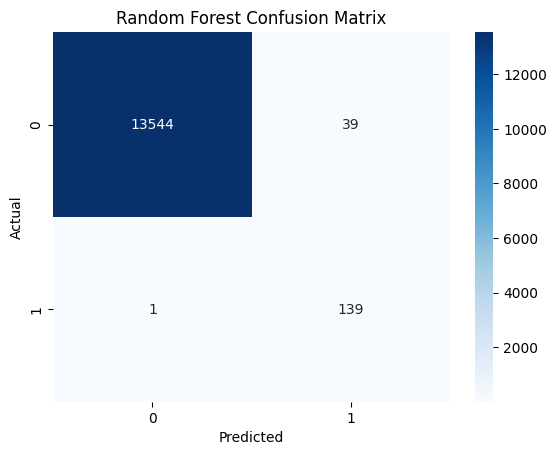

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Support Vector Machine(SVM)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)

X_test_scaled = scaler.transform(X_test_bal)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True)

svm_model.fit(X_train_bal_scaled, y_train_bal)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9735480580048095

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     13583
           1       0.28      0.99      0.43       140

    accuracy                           0.97     13723
   macro avg       0.64      0.98      0.71     13723
weighted avg       0.99      0.97      0.98     13723



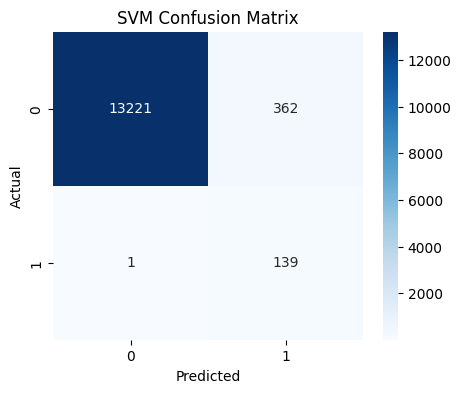

In [ ]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_bal, y_train_bal)

xgb_pred = xgb_model.predict(X_test_bal)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9986154630911608

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13583
           1       0.88      1.00      0.94       140

    accuracy                           1.00     13723
   macro avg       0.94      1.00      0.97     13723
weighted avg       1.00      1.00      1.00     13723



Neural Networks

In [ ]:
!pip install tensorflow

Epoch 1/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9636 - loss: 0.1198 - val_accuracy: 0.9953 - val_loss: 0.0359
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9828 - loss: 0.0554 - val_accuracy: 0.9949 - val_loss: 0.0351
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9836 - loss: 0.0512 - val_accuracy: 0.9932 - val_loss: 0.0391
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9842 - loss: 0.0480 - val_accuracy: 0.9968 - val_loss: 0.0267
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9847 - loss: 0.0467 - val_accuracy: 0.9972 - val_loss: 0.0327
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9846 - loss: 0.0455 - val_accuracy: 0.9968 - val_loss: 0.0366
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9853 - loss: 0.0449 - val_accuracy: 0.9980 - val_loss: 0.0312
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9859 - loss: 0.0442 - val_accuracy: 0.

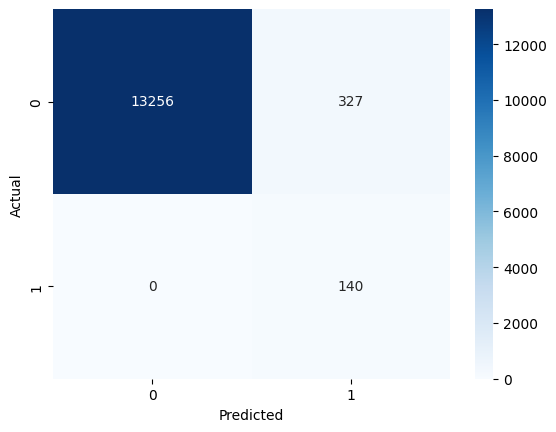

Neural Network model saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

model = tf.keras.Sequential([

    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_bal_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_bal_scaled,
    y_train_bal,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)

print("Neural Network Test Accuracy:", test_accuracy)

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

model.save("neural_network_model.h5")

print("Neural Network model saved successfully.")

Save and Download Models

In [ ]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("All models saved successfully.")

All models saved successfully.


In [ ]:
from google.colab import files

files.download("logistic_model.pkl")
files.download("random_forest_model.pkl")
files.download("svm_model.pkl")
files.download("xgboost_model.pkl")
files.download("neural_network_model.h5")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Test Models for Un-Seen Inputs**

In [ ]:
import joblib

log_model = joblib.load("logistic_model.pkl")
rf_model = joblib.load("random_forest_model.pkl")
svm_model = joblib.load("svm_model.pkl")
xgb_model = joblib.load("xgboost_model.pkl")

scaler = joblib.load("scaler.pkl")

nn_model = tf.keras.models.load_model("neural_network_model.h5")

print("Models loaded successfully.")

Models loaded successfully.


In [ ]:
# new_packet with 14 features (placeholder values - replace with your actual data)
# Features order: ['dst_port', 'inter_arrival_time', 'rolling_loss_rate', 'duplicate_ack_count', 'seq', 'duplicate_ack', 'jitter', 'ack', 'rtt_estimate', 'retransmission', 'retransmission_rate', 'lost_segment', 'src_port', 'timestamp']
new_packet = [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]

Test SVM

In [ ]:
new_scaled = scaler.transform(new_packet)

svm_prediction = svm_model.predict(new_scaled)
log_prediction = log_model.predict(new_scaled)

print("SVM:", "Packet Lost" if svm_prediction[0]==1 else "No Loss")
print("Logistic:", "Packet Lost" if log_prediction[0]==1 else "No Loss")

SVM: No Loss
Logistic: No Loss


In [ ]:
rf_prediction = rf_model.predict(new_packet)
xgb_prediction = xgb_model.predict(new_packet)

print("Random Forest:", "Packet Lost" if rf_prediction[0]==1 else "No Loss")
print("XGBoost:", "Packet Lost" if xgb_prediction[0]==1 else "No Loss")

Random Forest: No Loss
XGBoost: No Loss


In [ ]:
def predict_packet(packet_features):
    packet_scaled = scaler.transform(packet_features)

    results = {
        "Logistic": log_model.predict(packet_scaled)[0],
        "SVM": svm_model.predict(packet_scaled)[0],
        "Random Forest": rf_model.predict(packet_features)[0],
        "XGBoost": xgb_model.predict(packet_features)[0]
    }

    for model, pred in results.items():
        print(f"{model}: {'Packet Lost' if pred==1 else 'No Loss'}")

In [ ]:
predict_packet([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])

Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss


In [ ]:
i=1
for sample in [
    [34813, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], # Example with 14 features
    [56533, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [33365, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [94181, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [33365, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [113005, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [157893, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [137621, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [154997, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [163685, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
]:
    print("Sample: " + str(i))
    print(predict_packet([sample]))
    i+=1

Sample: 1
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 2
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 3
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 4
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 5
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 6
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 7
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 8
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 9
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None
Sample: 10
Logistic: No Loss
SVM: No Loss
Random Forest: No Loss
XGBoost: No Loss
None


Neural Network

In [ ]:
i = 1

for sample in [
    [34813, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [56533, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [33365, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [94181, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [33365, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [113005, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [157893, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [137621, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [154997, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [163685, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
]:

    sample_array = np.array([sample])

    sample_scaled = scaler.transform(sample_array)

    prob = nn_model.predict(sample_scaled, verbose=0)

    prediction = (prob > 0.5).astype(int)

    print(f"Sample {i}:")
    print("Input:", sample)
    print("Prediction:", "Packet Lost" if prediction[0][0] == 1 else "No Loss")
    print("Probability of Loss:", float(prob[0][0]))
    print("-" * 40)

    i += 1

Sample 1:
Input: [34813, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Prediction: No Loss
Probability of Loss: 0.0
----------------------------------------
Sample 2:
Input: [56533, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Prediction: No Loss
Probability of Loss: 0.0
----------------------------------------
Sample 3:
Input: [33365, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Prediction: No Loss
Probability of Loss: 0.0
----------------------------------------
Sample 4:
Input: [94181, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Prediction: No Loss
Probability of Loss: 0.0
----------------------------------------
Sample 5:
Input: [33365, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Prediction: No Loss
Probability of Loss: 0.0
----------------------------------------
Sample 6:
Input: [113005, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Prediction:

In [ ]:
i = 1

for sample, actual_label in [

    ([1200, 1200, 0, 1460, 0.004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0),            # No Loss
    ([34813, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 1),          # Loss
    ([3600, 3600, 0, 1460, 0.006, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0),            # No Loss
    ([56533, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 1),          # Loss
    ([94181, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 1),          # Loss
    ([2400, 2400, 0, 1460, 0.005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0),            # No Loss
    ([113005, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 1),         # Loss
    ([4800, 4800, 0, 1460, 0.0045, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0),           # No Loss
    ([157893, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 1),         # Loss
    ([33365, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 1),          # Loss
]:

    sample_array = np.array([sample])
    sample_scaled = scaler.transform(sample_array)

    prob = nn_model.predict(sample_scaled, verbose=0)
    prediction = (prob > 0.5).astype(int)

    print(f"Sample {i}:")
    print("Input:", sample)
    print("Actual:", "Packet Lost" if actual_label == 1 else "No Loss")
    print("Predicted:", "Packet Lost" if prediction[0][0] == 1 else "No Loss")
    print("Probability of Loss:", float(prob[0][0]))
    print("-" * 50)

    i += 1

Sample 1:
Input: [1200, 1200, 0, 1460, 0.004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Actual: No Loss
Predicted: No Loss
Probability of Loss: 0.0
--------------------------------------------------
Sample 2:
Input: [34813, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Actual: Packet Lost
Predicted: No Loss
Probability of Loss: 0.0
--------------------------------------------------
Sample 3:
Input: [3600, 3600, 0, 1460, 0.006, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Actual: No Loss
Predicted: No Loss
Probability of Loss: 0.0
--------------------------------------------------
Sample 4:
Input: [56533, 29, 0, 2896, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Actual: Packet Lost
Predicted: No Loss
Probability of Loss: 0.0
--------------------------------------------------
Sample 5:
Input: [94181, 29, 0, 1448, 0.013406, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Actual: Packet Lost
Predicted: No Loss
Probability of Loss: 0.0
-----------------------